Step :1 Import Libraries


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
pd.set_option('display.max_columns', None)

Step :2 LOAD DATASET


In [21]:
df = pd.read_csv(r"Dataset for Data visualization.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


Step :3 DATA CLEANING


In [22]:
print("\nMissing Values:")
print(df.isnull().sum())

if 'CouponCode' in df.columns:
    df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

if 'ReferralSource' in df.columns:
    df['ReferralSource'] = df['ReferralSource'].fillna('Unknown')

df.drop_duplicates(inplace=True)

df['Date'] = pd.to_datetime(df['Date'],dayfirst=True,errors='coerce')

df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

month_order=['january','february','march','april','may','june','july','august','september','october','november','december']

df.to_csv("Cleaned_Dataset.csv", index=False)

print("Cleaned Dataset Saved Successfully")
print("New Shape:",df.shape)



Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64
Cleaned Dataset Saved Successfully
New Shape: (1200, 16)


Step :4 BUSINESS OVERVIEW

In [23]:
total_revenue = df['TotalPrice'].sum()
total_orders = df['OrderID'].nunique()
total_customers = df['CustomerID'].nunique()

print("\nBUSINESS OVERVIEW")
print("Total Revenue:", round(total_revenue,2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)



BUSINESS OVERVIEW
Total Revenue: 1264761.96
Total Orders: 1200
Total Customers: 1189


Step :5 Monthly Revenue Trend

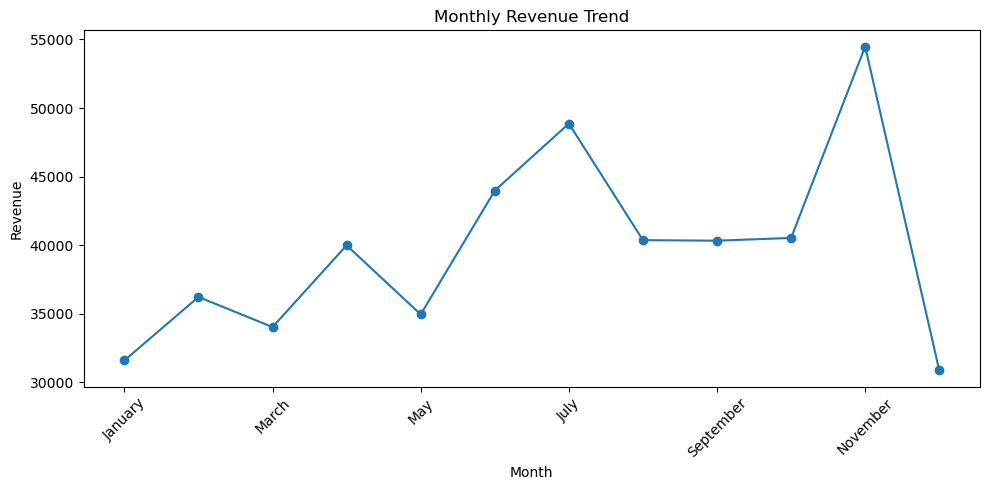


Insight:
November recorded the highest revenue.

Recommendation:
Analyze successful campaigns during peak periods.


In [24]:
monthly_revenue = (
    df.groupby(df['Date'].dt.month_name())['TotalPrice']
    .sum()
)

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_revenue = monthly_revenue.reindex(month_order)

plt.figure(figsize=(10,5))
monthly_revenue.plot(marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("monthly_revenue_trend.png")
plt.show()

print("\nInsight:")
print(f"{monthly_revenue.idxmax()} recorded the highest revenue.")

print("\nRecommendation:")
print("Analyze successful campaigns during peak periods.")



Step:6 Top Revenue Products


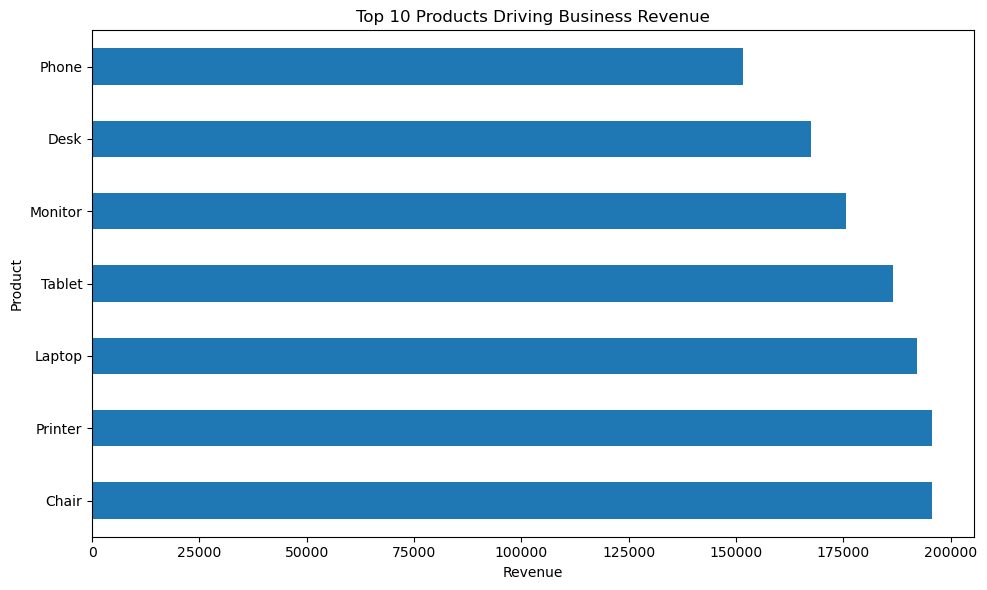

Insight:
Chair generated the highest revenue.

Recommendation:
Increase inventory and promotions for top products.


In [25]:
top_products = (
    df.groupby('Product')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh')
plt.title("Top 10 Products Driving Business Revenue")
plt.xlabel("Revenue")
plt.tight_layout()
plt.savefig("top_products_revenue.png")
plt.show()

best_product_chart = top_products.idxmax()

print("Insight:")
print(f"{best_product_chart} generated the highest revenue.")

print("\nRecommendation:")
print("Increase inventory and promotions for top products.")

Step :7 Payment Method Distribution


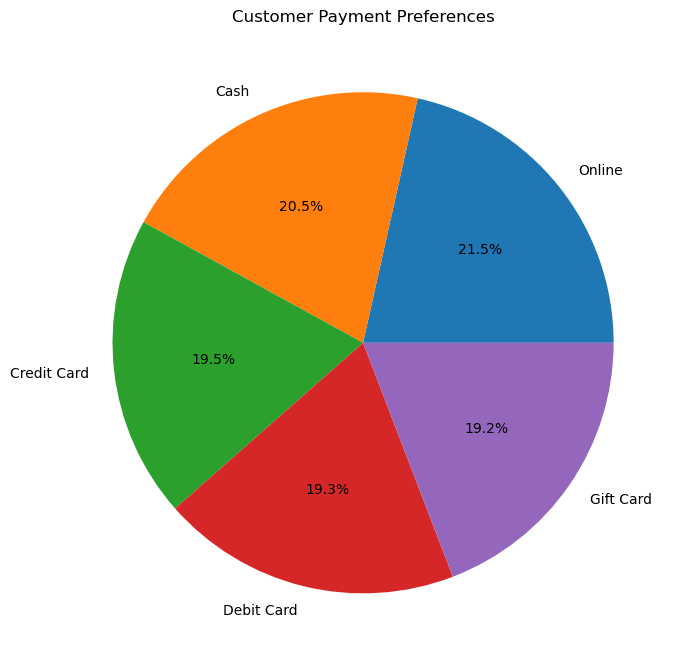

Insight:
Online is the most preferred payment method.

Recommendation:
Ensure a seamless payment experience.


In [26]:
payment = df['PaymentMethod'].value_counts()

plt.figure(figsize=(7,7))
payment.plot(kind='pie', autopct='%1.1f%%')
plt.title("Customer Payment Preferences")
plt.ylabel("")
plt.tight_layout()
plt.savefig("payment_distribution.png")
plt.show()

top_payment = payment.idxmax()

print("Insight:")
print(f"{top_payment} is the most preferred payment method.")

print("\nRecommendation:")
print("Ensure a seamless payment experience.")

Step :8 Order Status Analysis


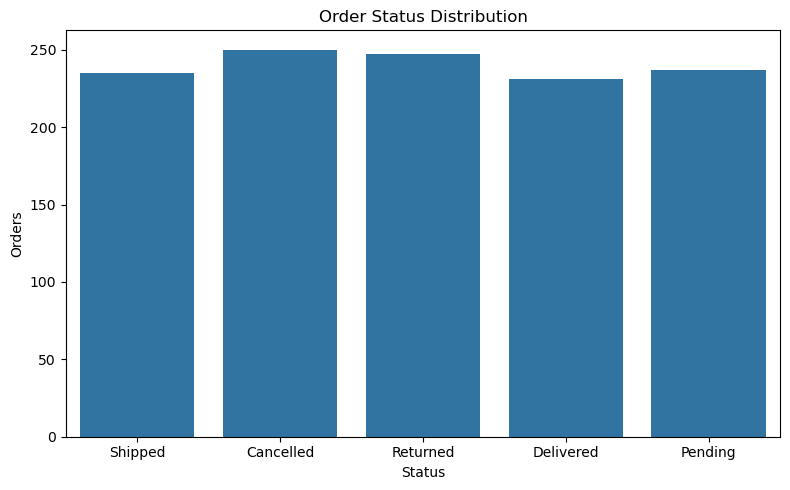

Insight:
Order status reflects operational efficiency.

Recommendation:
Reduce cancellations and improve delivery success.


In [27]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='OrderStatus')
plt.title("Order Status Distribution")
plt.xlabel("Status")
plt.ylabel("Orders")
plt.tight_layout()
plt.savefig("order_status_distribution.png")
plt.show()

print("Insight:")
print("Order status reflects operational efficiency.")

print("\nRecommendation:")
print("Reduce cancellations and improve delivery success.")


Step :9 Referral Source Performance


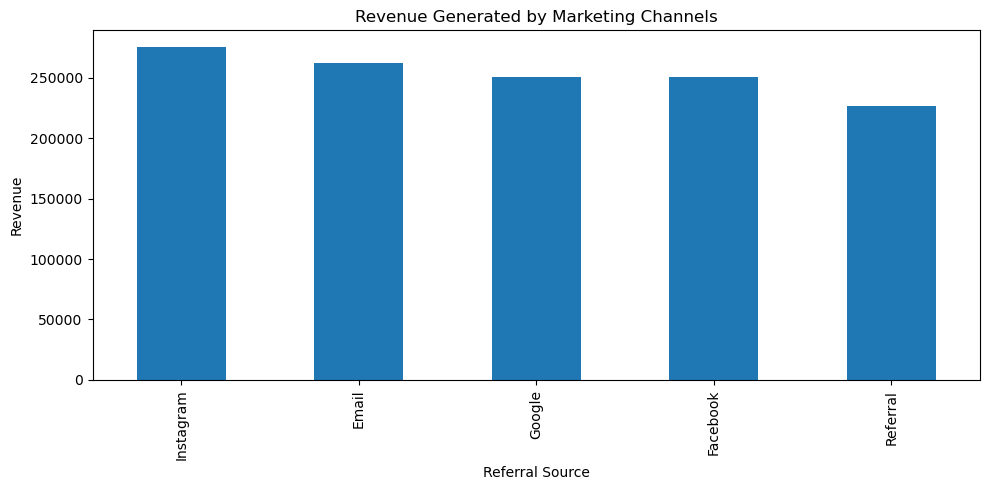

Insight:
Instagram generates the highest revenue.

Recommendation:
Invest more in this marketing channel.


In [28]:
referral = (
    df.groupby('ReferralSource')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
referral.plot(kind='bar')
plt.title("Revenue Generated by Marketing Channels")
plt.xlabel("Referral Source")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("referral_source_revenue.png")
plt.show()

best_channel_chart = referral.idxmax()

print("Insight:")
print(f"{best_channel_chart} generates the highest revenue.")

print("\nRecommendation:")
print("Invest more in this marketing channel.")


Step :10 Quantity vs Revenue


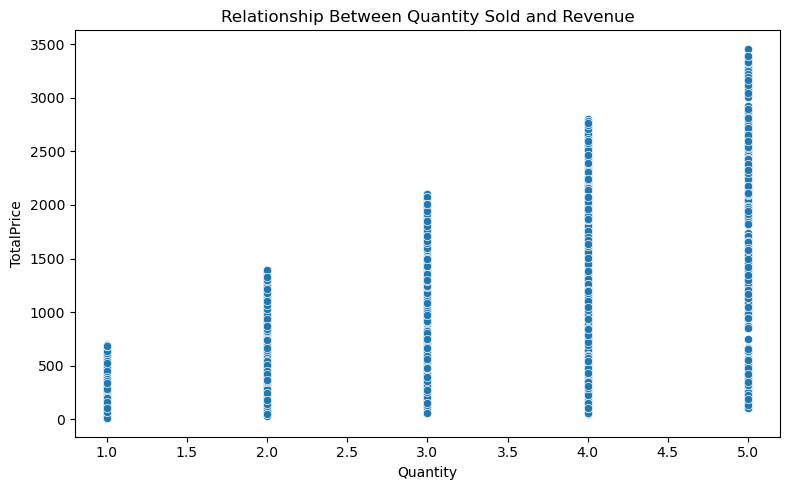

Insight:
Higher quantities generally increase revenue.

Recommendation:
Promote bundle offers and bulk purchases.


In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Quantity', y='TotalPrice')

plt.title("Relationship Between Quantity Sold and Revenue")
plt.tight_layout()
plt.savefig("quantity_vs_revenue.png")
plt.show()

print("Insight:")
print("Higher quantities generally increase revenue.")

print("\nRecommendation:")
print("Promote bundle offers and bulk purchases.")

Step 11: Monthly Order Trend

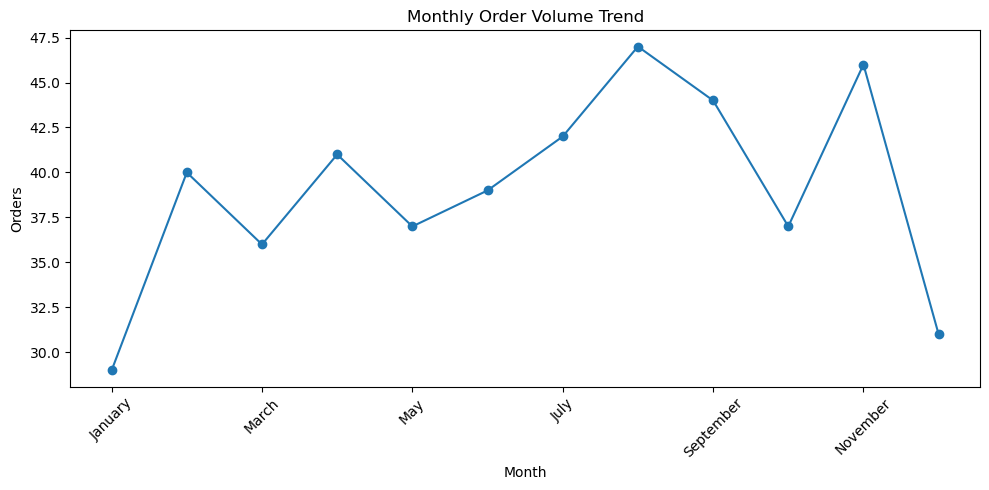


Insight:
August recorded the highest number of orders.

Recommendation:
Prepare inventory and logistics resources for peak periods.


In [30]:
monthly_orders = (
    df.groupby(df['Date'].dt.month_name())['OrderID']
    .count()
)

monthly_orders = monthly_orders.reindex(month_order)

plt.figure(figsize=(10,5))
monthly_orders.plot(marker='o')

plt.title("Monthly Order Volume Trend")
plt.xlabel("Month")
plt.ylabel("Orders")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("monthly_orders_trend.png")
plt.show()

print("\nInsight:")
print(f"{monthly_orders.idxmax()} recorded the highest number of orders.")

print("\nRecommendation:")
print("Prepare inventory and logistics resources for peak periods.")

Step 12: Correlation Heatmap

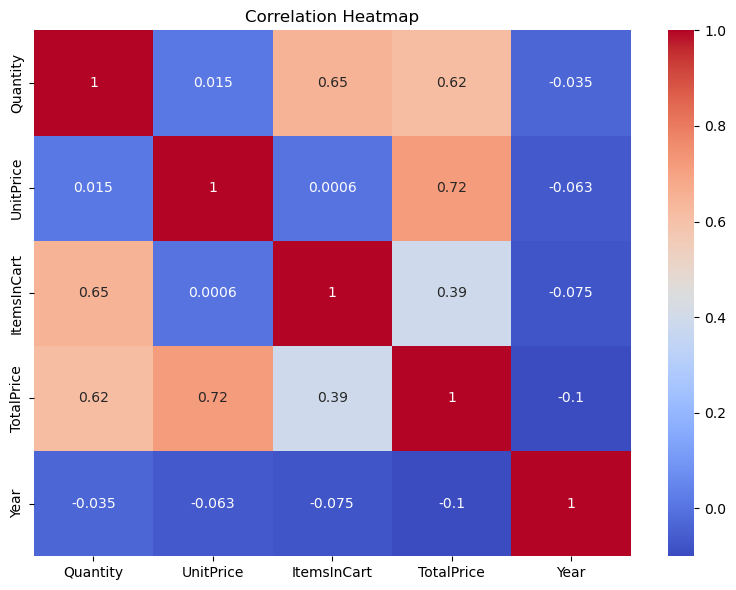


Insight:
The heatmap highlights relationships among numerical variables.

Recommendation:
Focus on variables strongly correlated with revenue.


In [31]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

print("\nInsight:")
print("The heatmap highlights relationships among numerical variables.")

print("\nRecommendation:")
print("Focus on variables strongly correlated with revenue.")

Step 13: Executive Insights

In [32]:
best_product = (
    df.groupby('Product')['TotalPrice']
    .sum()
    .idxmax()
)

best_channel = (
    df.groupby('ReferralSource')['TotalPrice']
    .sum()
    .idxmax()
)

best_payment = df['PaymentMethod'].mode()[0]
common_status = df['OrderStatus'].mode()[0]

print("="*60)
print("EXECUTIVE INSIGHTS")
print("="*60)

print(f"""
BUSINESS PERFORMANCE SUMMARY

Total Revenue Generated : ₹{total_revenue:,.2f}

Total Orders Processed : {total_orders}

Total Customers Served : {total_customers}

Highest Revenue Product : {best_product}

Best Marketing Channel : {best_channel}

Preferred Payment Method : {best_payment}

Most Common Order Status : {common_status}
""")

print("="*60)
print("KEY RECOMMENDATIONS")
print("="*60)

print("1. Increase investment in top-performing products.")
print("2. Allocate more budget to the best-performing marketing channel.")
print("3. Improve order fulfillment efficiency.")
print("4. Prepare inventory for peak-demand periods.")
print("5. Enhance customer experience around preferred payment methods.")

print("\nProject Completed Successfully!")

print("\nGenerated Files:")
print("✔ Cleaned_Dataset.csv")
print("✔ monthly_revenue_trend.png")
print("✔ top_products_revenue.png")
print("✔ payment_distribution.png")
print("✔ order_status_distribution.png")
print("✔ referral_source_revenue.png")
print("✔ quantity_vs_revenue.png")
print("✔ monthly_orders_trend.png")
print("✔ correlation_heatmap.png")

EXECUTIVE INSIGHTS

BUSINESS PERFORMANCE SUMMARY

Total Revenue Generated : ₹1,264,761.96

Total Orders Processed : 1200

Total Customers Served : 1189

Highest Revenue Product : Chair

Best Marketing Channel : Instagram

Preferred Payment Method : Online

Most Common Order Status : Cancelled

KEY RECOMMENDATIONS
1. Increase investment in top-performing products.
2. Allocate more budget to the best-performing marketing channel.
3. Improve order fulfillment efficiency.
4. Prepare inventory for peak-demand periods.
5. Enhance customer experience around preferred payment methods.

Project Completed Successfully!

Generated Files:
✔ Cleaned_Dataset.csv
✔ monthly_revenue_trend.png
✔ top_products_revenue.png
✔ payment_distribution.png
✔ order_status_distribution.png
✔ referral_source_revenue.png
✔ quantity_vs_revenue.png
✔ monthly_orders_trend.png
✔ correlation_heatmap.png
